# Roulette Resimulation (Experiment July 2026)

We build on [](xref:cosmoai/demo03resimulation/).
The following modules are needed.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tomllib as tl

from CosmoSim.datagen import SimImage
import CosmoSim.Image as csimg
from CosmoSim import Parameters
from CosmoSim.roulettegen import Resim

import CosmoSim as cs
print( "CosmoSim version", cs.__version__ )

CosmoSim version 3.3.0


::: {warning} Version requirement
This report assumes the features introduced in CosmoSim v3.3.
Using v3.2.4, the code will run, but the discrepnacies reported
in the last test will also be present in the previous tests
using the `Resim` class.
:::

We will also need the following files, which will be loaded by 
the code:
+ [sie-dataset.toml](sie-dataset.toml).
+ [sie-dataset.csv](sie-dataset.csv).
+ [sie-testing.csv](sie-testing.csv).
+ [pred-sie-testing.csv](pred-sie-testing.csv).

## Review of the SIE experiment data

We load and compare the testing results and the ground truth.

In [2]:
gt = pd.read_csv( "sie-testing.csv", index_col="filename" )
pr = pd.read_csv( "pred-sie-testing.csv", index_col="filename" )
rawerrors = gt - pr
sse = (rawerrors**2).sum(axis=1)

From the dataset, we pick the three best and the three worst data points.

In [3]:
best = list(sse.nlargest(3).index)
worst = list(sse.nsmallest(3).index)
print( "Best:", best )
print( "Worst:", worst )

Best: ['image-013985.png', 'image-012507.png', 'image-012157.png']
Worst: ['image-013337.png', 'image-011726.png', 'image-011188.png']


## Simulation from lens parameters

To simulate the images, we need to load the parameters from
`sie-dataset.csv`.
From this dataset we pick just the selected rows.

In [4]:
df = pd.read_csv( "sie-dataset.csv", index_col="filename" )
df = df.loc[best+worst]
display( df )

,index,model,einsteinradius,ellipseratio,orientation,lens,source,R,phi,sigma,sigma2,theta,n_sersic,luminosity,x,y
filename,,,,,,,,,,,,,,,,
image-013985.png,13985,Raytrace,69.6013,0.2768,95.8467,SIE,SersicSphere,24.1802,77.7199,23.1361,18.9669,162.2368,3.1563,44.0993,5.1429,23.6270
image-012507.png,12507,Raytrace,73.1703,0.4100,67.6020,SIE,SersicSphere,42.5148,244.0716,38.2267,9.7750,142.2957,1.5813,62.6764,-18.5895,-38.2353
image-012157.png,12157,Raytrace,37.6196,0.3916,84.1959,SIE,SersicSphere,13.4863,85.5608,42.2883,34.5082,153.4485,1.7682,48.9226,1.0438,13.4458
image-013337.png,13337,Raytrace,14.2685,0.1355,89.2897,SIE,SersicSphere,9.9496,281.3395,42.2037,31.9985,151.5437,4.5882,53.0431,1.9563,-9.7554
image-011726.png,11726,Raytrace,2.7635,0.5743,179.7125,SIE,SersicSphere,2.5768,138.6969,15.8369,20.4272,66.1726,4.2381,60.4668,-1.9357,1.7008
image-011188.png,11188,Raytrace,32.4431,0.6427,55.0690,SIE,SersicSphere,20.4794,341.6332,18.4612,28.5004,90.0176,3.1659,31.6724,19.4362,-6.4530


We will also need the simulator configuration from `sie-dataset.toml`.

In [5]:
with open( "sie-dataset.toml", 'rb' ) as f:
            toml = tl.load(f)
param = Parameters( toml )

Now we can run the simulator.

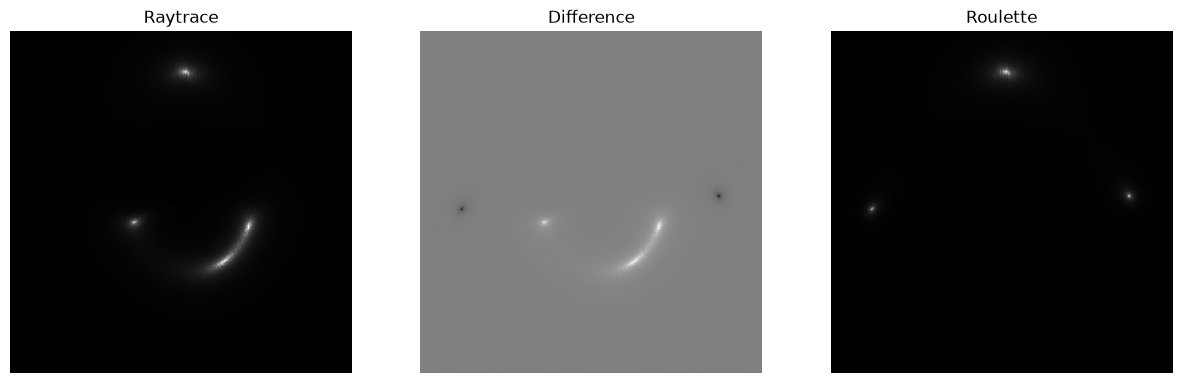

In [6]:
param.setRow( df.iloc[0] )
param["simulator"]["centred"] = False
imsim0 = SimImage( param, verbose=0 )
ray0 = imsim0.getImage()
param["simulator"]["model"] = "Roulette" 
rousim0 = SimImage( param, verbose=0 )
rou0 = rousim0.getImage()
csimg.imageCompare( ray0, rou0, "Raytrace", "Roulette" ) 

We can also get annotations on the images, like this:

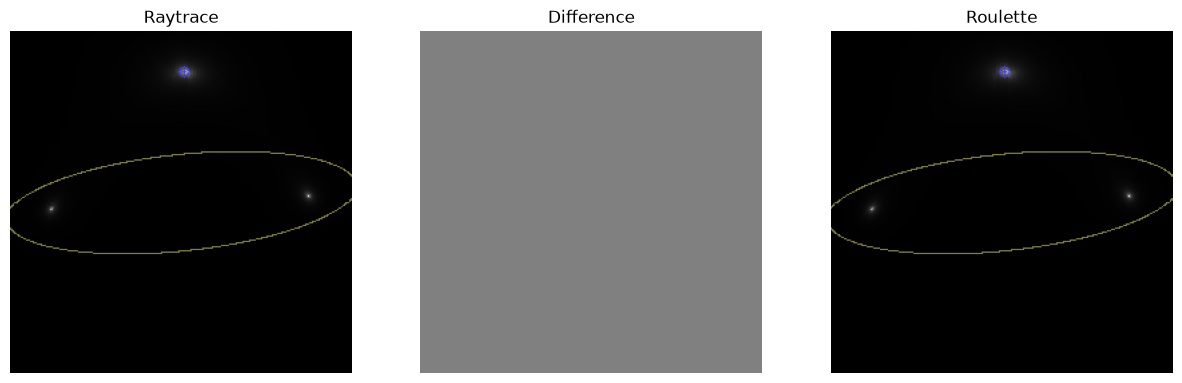

In [7]:
param.setRow( df.iloc[0] )
param["simulator"]["centred"] = False
ray0a = rousim0.getAnnotated(convergenceRing=None,centrePoint=None)
param["simulator"]["model"] = "Roulette" 
rou0a = rousim0.getAnnotated(convergenceRing=None,centrePoint=None)
csimg.imageCompare( ray0a, rou0a, "Raytrace", "Roulette" ) 

The roulette simulation seems perfect within the convergence ring.

::: {warning}
The call to `setRow()` overrides settings which have been set
manually.  Hense we need to reset `simulator.centred` each time,
but we do not have to reset `simulator.model` to Raytrace after the
roulette simulation.
:::

## The full image set

We can repeat the simulation on all the selected imags.

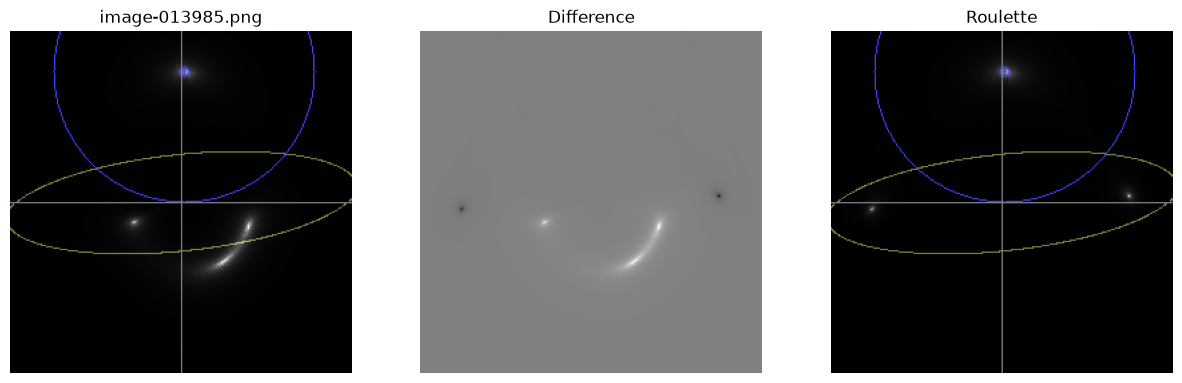

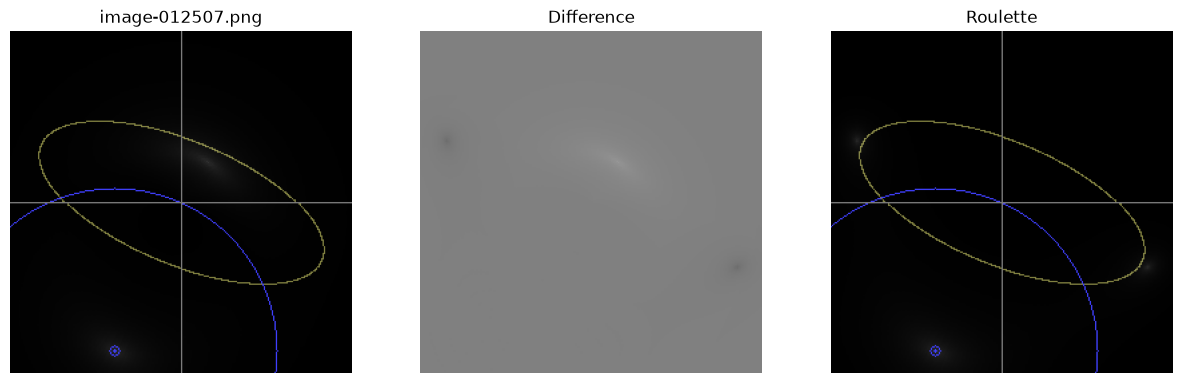

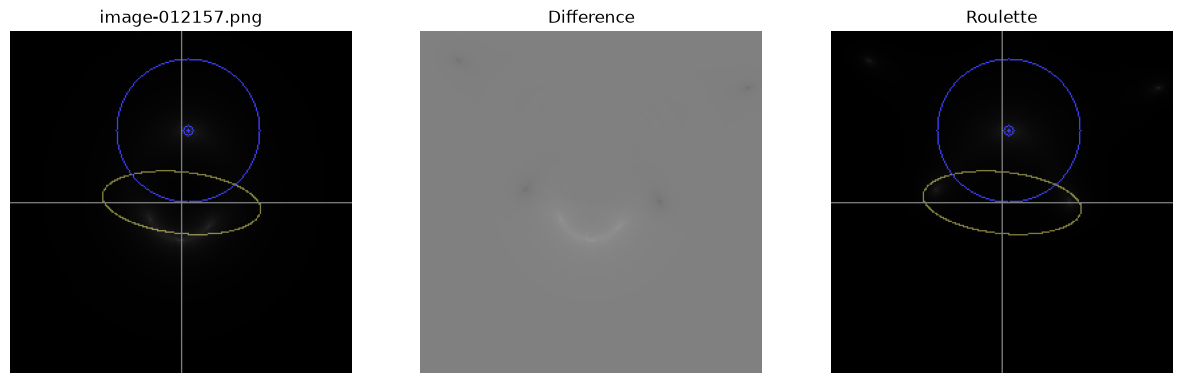

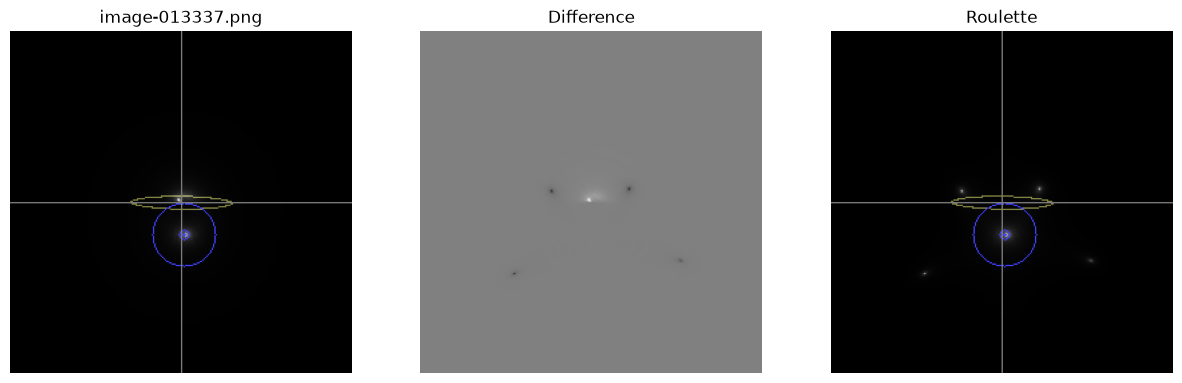

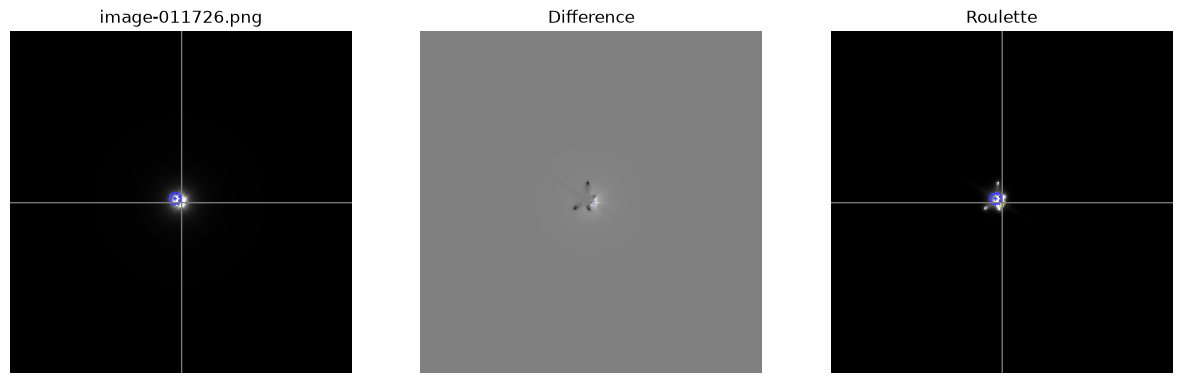

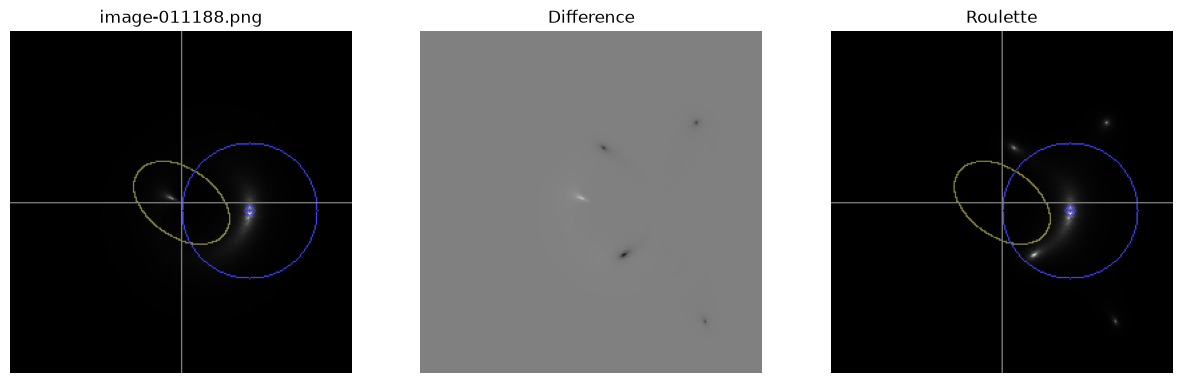

In [8]:
for index, row in df.iterrows():
    param.setRow( row )
    param["simulator"]["centred"] = False
    ray = SimImage( param, verbose=0
        ).getAnnotated(centrePoint=None)
    param["simulator"]["model"] = "Roulette" 
    rou = SimImage( param, verbose=0
        ).getAnnotated(centrePoint=None)
    csimg.imageCompare( ray, rou, index, "Roulette", axiscross=True ) 

Here we observe very good match between the roulette and raytrace
simulations, except possibly where the visible image is tiny and centred,
where it is difficult to judge.

## Resimulation

It will be interesting to check if resimulation confirms the result.
First a simple check with a single data point.

In [9]:
row = imsim0.getData()
display( row )

filename       image-011188.png
source             SersicSphere
x                       19.4362
y                        -6.453
sigma                   18.4612
sigma2                  28.5004
theta                   90.0176
luminosity              31.6724
n_sersic                 3.1659
lensX                         0
lensY                         0
centreX                       0
centreY                       0
reletaX                  5.1429
reletaY                  23.627
offsetX                0.004848
offsetY               77.495702
xiX                    2.056065
xiY                    98.03102
alpha[0][1]            3.091682
alpha[1][0]           -0.188041
alpha[1][2]           -0.187875
alpha[2][1]           -0.000268
alpha[2][3]            0.000072
alpha[3][0]           -0.000029
alpha[3][2]             0.00004
alpha[3][4]            0.000069
alpha[4][1]                -0.0
alpha[4][3]                 0.0
alpha[4][5]                -0.0
beta[0][1]           -74.404122
beta[1][

[getSource] src=SersicSphere, ltprf0=None, verbose=1
[SphericalSource] constructor done


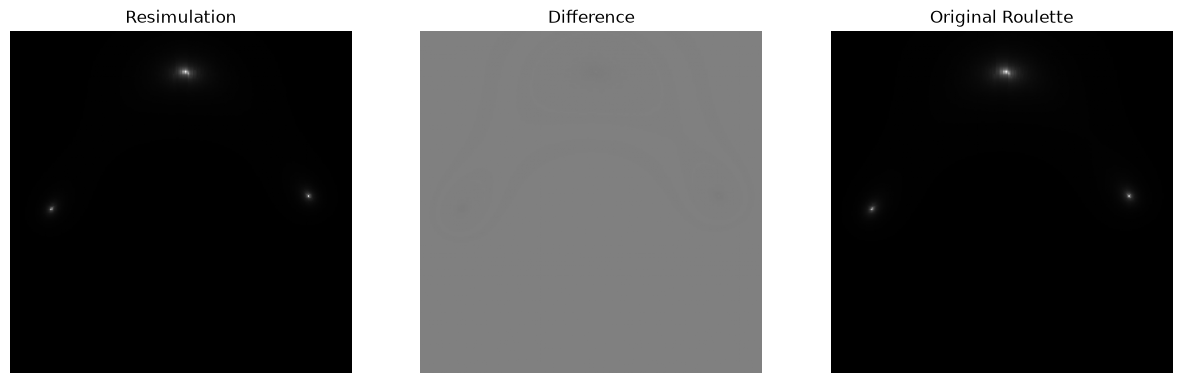

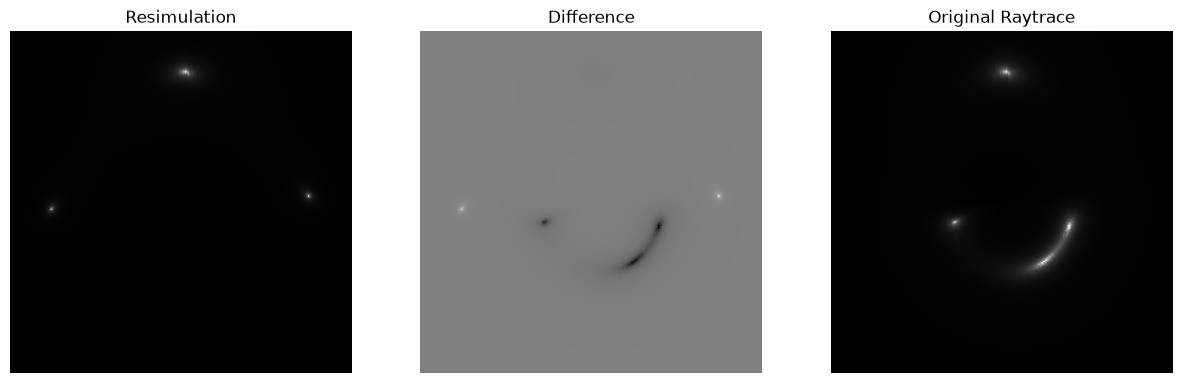

In [10]:
rp = Parameters( { "simulator" : { "cropsize" : 256 } } )
resimImage = Resim(  row, rp, verbose=0 ).getImage()
csimg.imageCompare( resimImage, rou0, "Resimulation", "Original Roulette" )
csimg.imageCompare( resimImage, ray0, "Resimulation", "Original Raytrace" )

This looks perfect as far as the roulette formalism goes, as do the other selected images.

::: {note} Primary image
Possibly confusing, the larger of the distorted images fall outside the convergence ring. The primary image on which the roulette representation focuses, is comparatively small.
:::

[getSource] src=SersicSphere, ltprf0=None, verbose=1
[SphericalSource] constructor done


[getSource] src=SersicSphere, ltprf0=None, verbose=1
[SphericalSource] constructor done


[getSource] src=SersicSphere, ltprf0=None, verbose=1
[SphericalSource] constructor done


[getSource] src=SersicSphere, ltprf0=None, verbose=1
[SphericalSource] constructor done


[getSource] src=SersicSphere, ltprf0=None, verbose=1
[SphericalSource] constructor done


[getSource] src=SersicSphere, ltprf0=None, verbose=1
[SphericalSource] constructor done


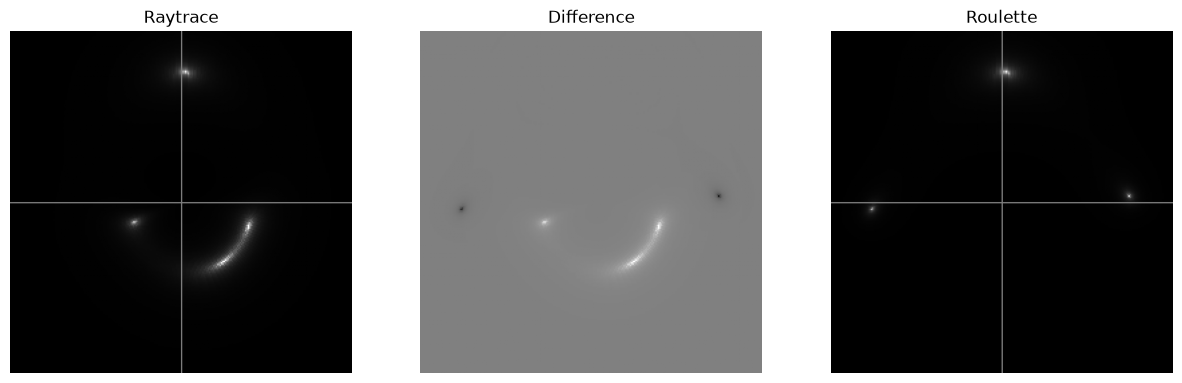

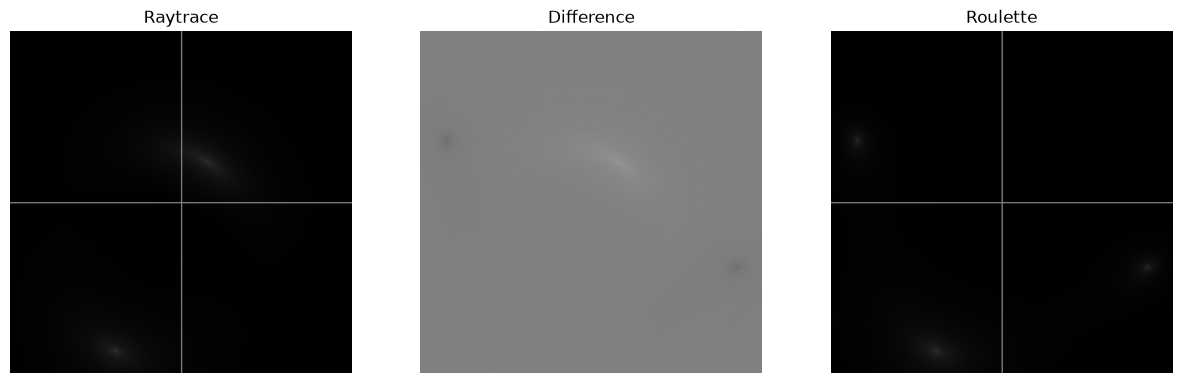

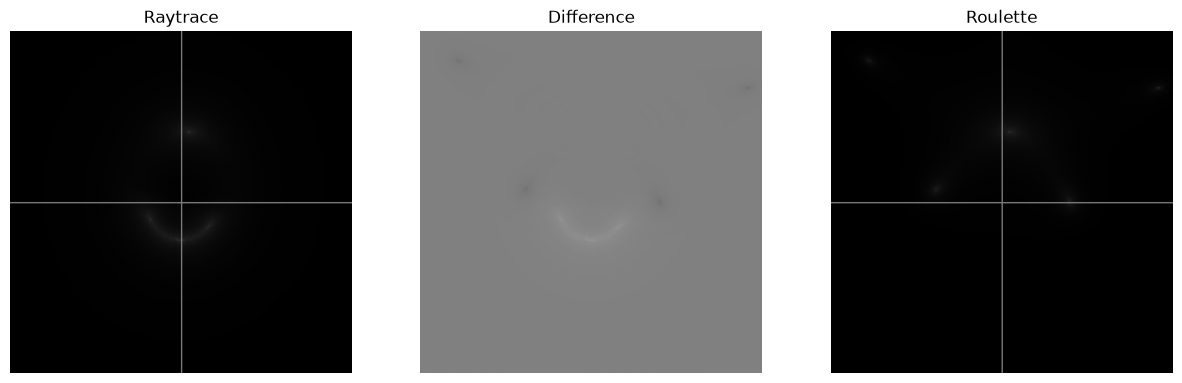

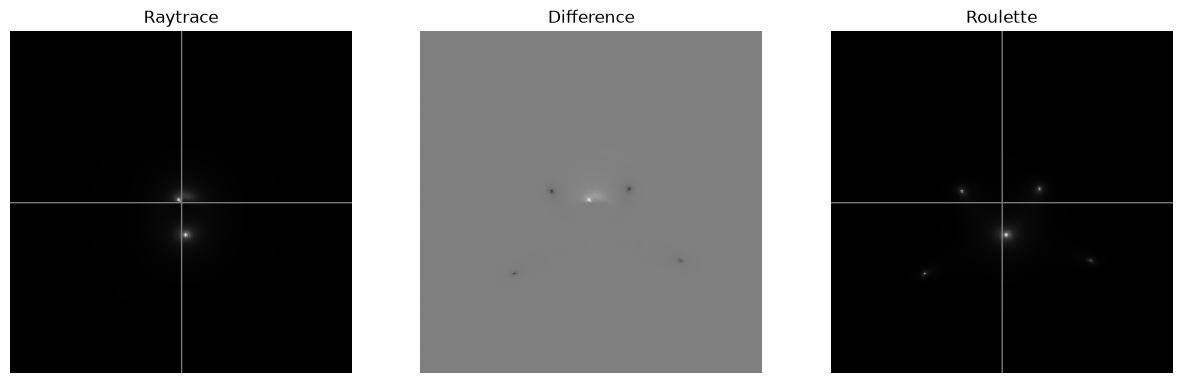

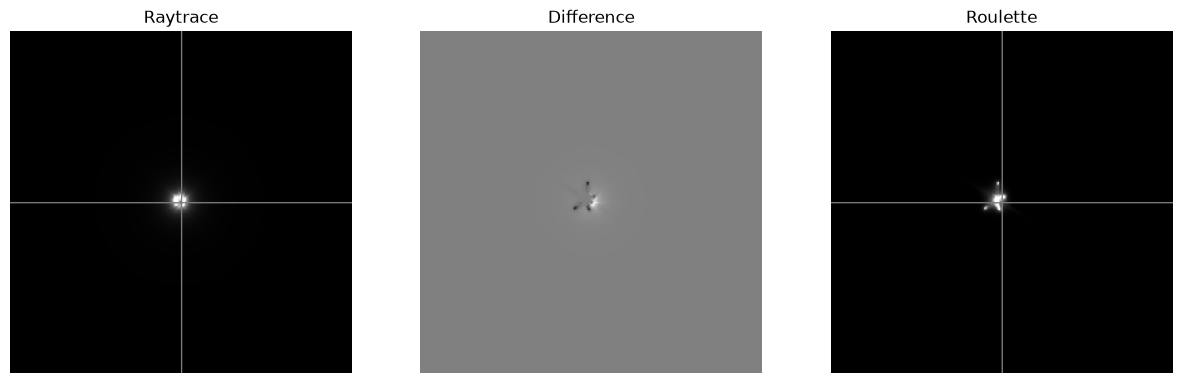

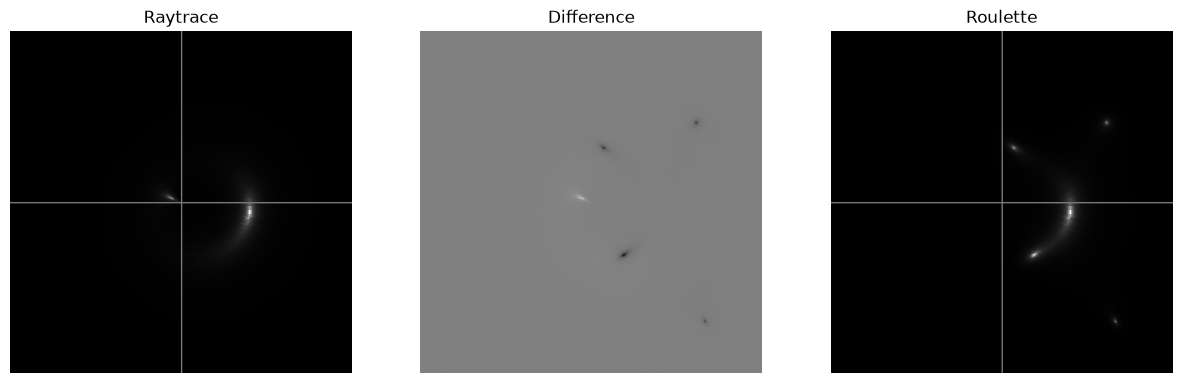

In [11]:
for index, row in df.iterrows():
    param.setRow( row )
    param["simulator"]["centred"] = False
    imsim = SimImage( param, verbose=0 )
    ray = imsim.getImage()
    rr = imsim.getData()
    rou = Resim( rr, rp, verbose=0 ).getImage()
    csimg.imageCompare( ray, rou, "Raytrace", "Roulette", axiscross=True ) 

Note that we have simulated without centring.

In [12]:
print( "Centring:", param.get( "centred" ) )

Centring: False


## Centred mode

Let us reset the simulator to use centred mode.

In [13]:
with open( "sie-dataset.toml", 'rb' ) as f:
            toml = tl.load(f)
param = Parameters( toml )

[getSource] src=SersicSphere, ltprf0=None, verbose=1
[SphericalSource] constructor done


[getSource] src=SersicSphere, ltprf0=None, verbose=1
[SphericalSource] constructor done


[getSource] src=SersicSphere, ltprf0=None, verbose=1
[SphericalSource] constructor done


[getSource] src=SersicSphere, ltprf0=None, verbose=1
[SphericalSource] constructor done


[getSource] src=SersicSphere, ltprf0=None, verbose=1
[SphericalSource] constructor done


[getSource] src=SersicSphere, ltprf0=None, verbose=1
[SphericalSource] constructor done


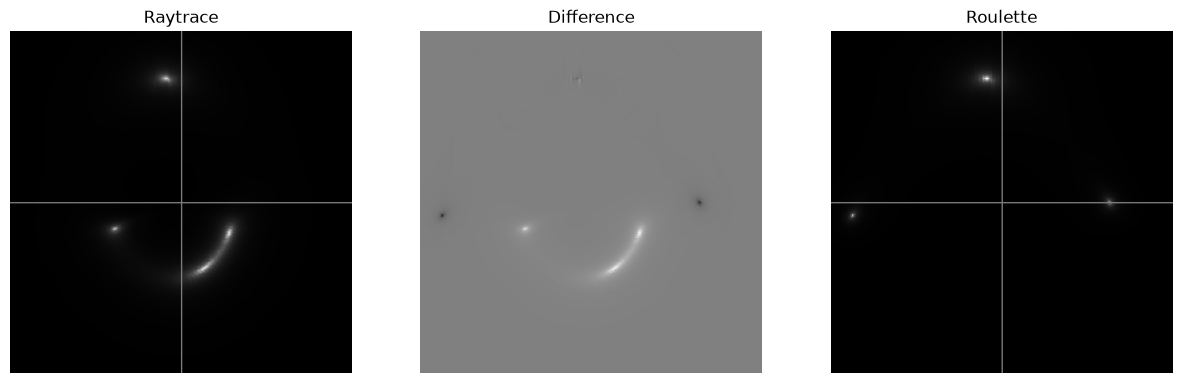

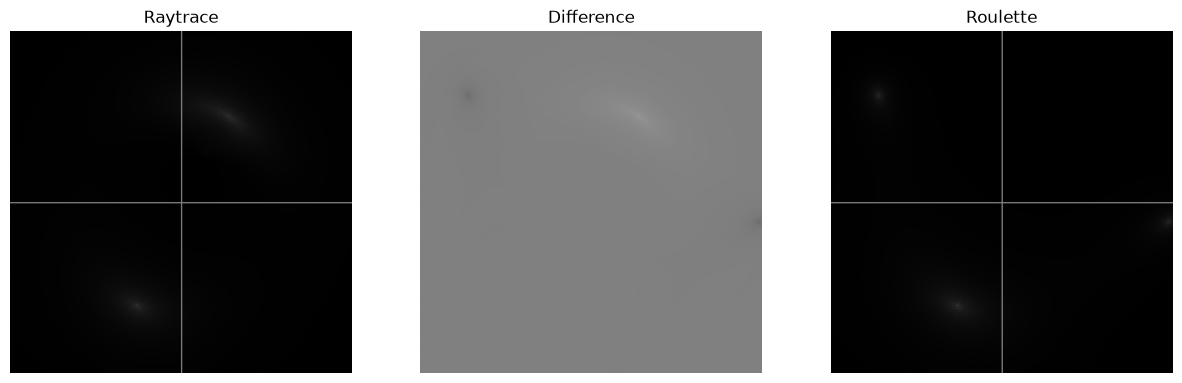

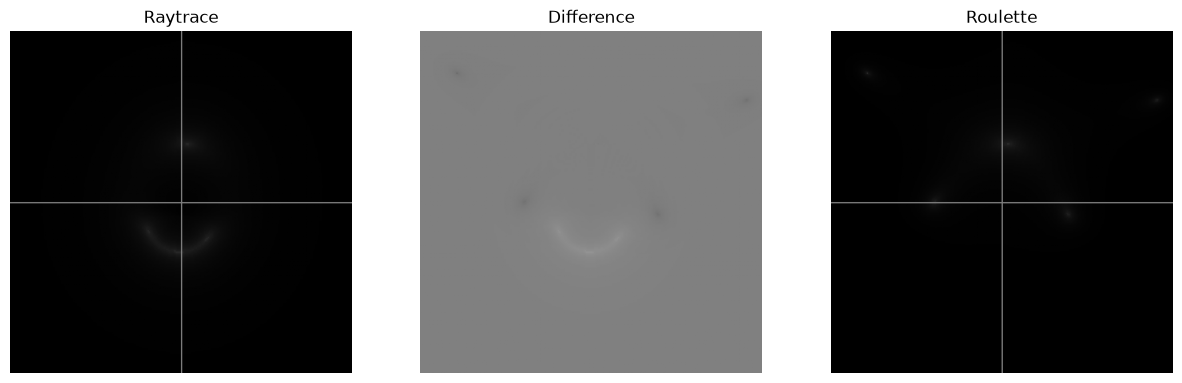

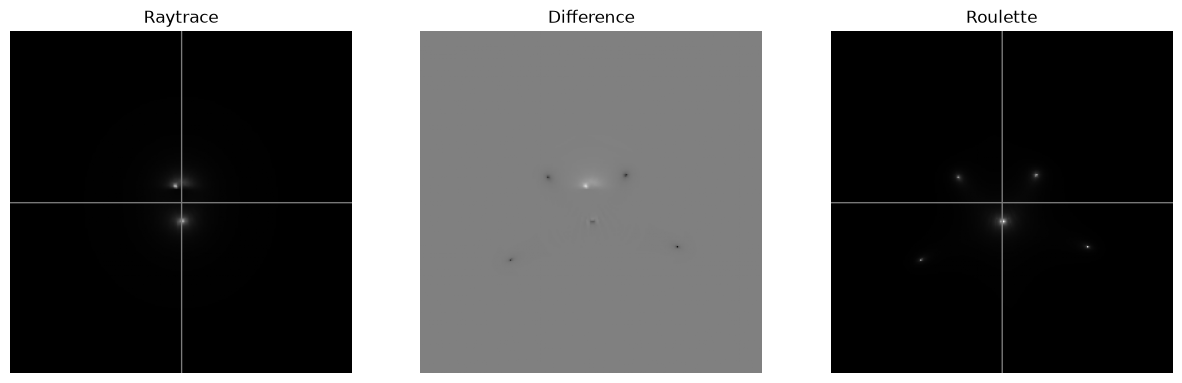

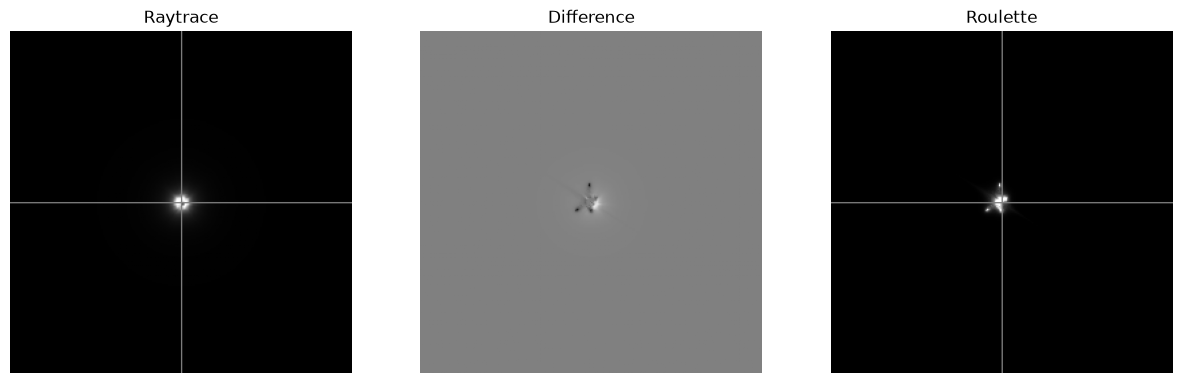

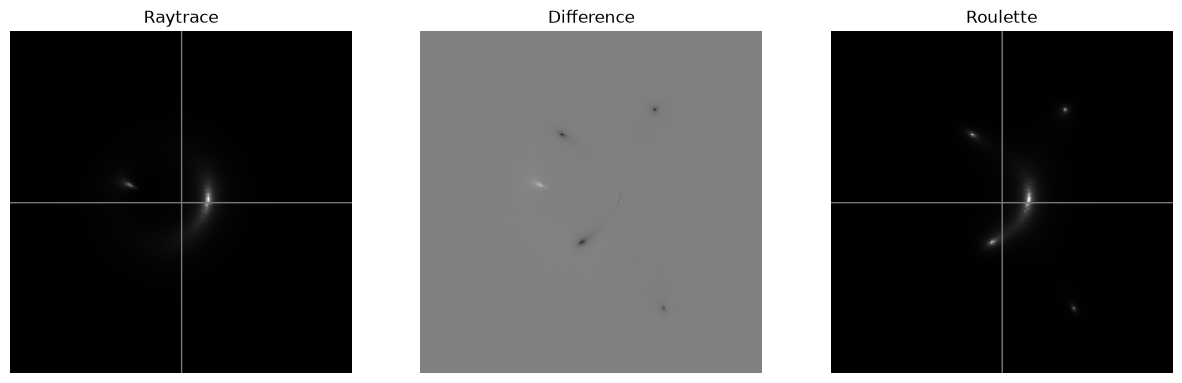

In [14]:
for index, row in df.iterrows():
    param.setRow( row )
    imsim = SimImage( param, verbose=0 )
    ray = imsim.getImage()
    rr = imsim.getData()
    rou = Resim( rr, rp, verbose=0 ).getImage()
    csimg.imageCompare( ray, rou, "Raytrace", "Roulette", axiscross=True ) 

This is also perfect.

## Validation of the generated amplitudes

During the debugging phase, we also check the amplitudes generated here against the file generated by the batch run.  Although this did not give any answers at the time, we give the code in case it may be useful in the future.

In [15]:
gt = pd.read_csv( "sie-roulette.csv", index_col="filename" )
gt = gt.loc[best+worst]
display( gt )

,source,x,y,sigma,sigma2,theta,luminosity,n_sersic,lensX,lensY,...,beta[1][0],beta[1][2],beta[2][1],beta[2][3],beta[3][0],beta[3][2],beta[3][4],beta[4][1],beta[4][3],beta[4][5]
filename,,,,,,,,,,,,,,,,,,,,,
image-013985.png,SersicSphere,5.1429,23.6270,23.1361,18.9669,162.2368,44.0993,3.1563,-14.518626,-4.960226,...,0.0,0.007884,0.002883,0.002878,0.0,0.000007,-0.000001,1.459410e-06,-8.222899e-07,-2.271159e-06
image-012507.png,SersicSphere,-18.5895,-38.2353,38.2267,9.7750,142.2957,62.6764,1.5813,16.034957,33.979595,...,0.0,0.145103,-0.002195,-0.000708,0.0,-0.000020,-0.000046,-6.788833e-07,1.817044e-07,-6.359311e-07
image-012157.png,SersicSphere,1.0438,13.4458,42.2883,34.5082,153.4485,48.9226,1.7682,-1.233324,-9.246201,...,0.0,0.039167,0.005989,0.005793,0.0,-0.000031,-0.000094,9.427976e-06,-6.036643e-06,-1.414435e-05
image-013337.png,SersicSphere,1.9563,-9.7554,42.2037,31.9985,151.5437,53.0431,4.5882,-2.509759,10.363519,...,0.0,-0.021439,-0.006869,-0.006605,0.0,-0.000007,0.000215,-5.930895e-05,3.074611e-05,8.105347e-05
image-011726.png,SersicSphere,-1.9357,1.7008,15.8369,20.4272,66.1726,60.4668,4.2381,1.396268,-1.312222,...,0.0,-0.195486,0.013336,-0.060923,0.0,0.010305,-0.024217,3.698170e-03,7.803674e-03,-9.474008e-03
image-011188.png,SersicSphere,19.4362,-6.4530,18.4612,28.5004,90.0176,31.6724,3.1659,-31.039314,9.715073,...,0.0,-0.078995,0.003390,0.002016,0.0,-0.000143,-0.000115,-8.928248e-06,1.212198e-05,9.166790e-06


We did not store the amplitudes from `getData` when we did the simulation, so we need to create a DataFrame of these amplitudes now.

In [16]:
l = []
for index, row in df.iterrows():
    param.setRow( row )
    imsim = SimImage( param, verbose=0 )
    l.append( imsim.getData() )
gen = pd.DataFrame( l )
display( gen )

,filename,source,x,y,sigma,sigma2,theta,luminosity,n_sersic,lensX,...,beta[1][0],beta[1][2],beta[2][1],beta[2][3],beta[3][0],beta[3][2],beta[3][4],beta[4][1],beta[4][3],beta[4][5]
image-013985.png,image-013985.png,SersicSphere,5.1429,23.6270,23.1361,18.9669,162.2368,44.0993,3.1563,-14.518626,...,0.0,0.007884,0.002883,0.002878,0.0,0.000007,-0.000001,1.459410e-06,-8.222899e-07,-2.271159e-06
image-012507.png,image-012507.png,SersicSphere,-18.5895,-38.2353,38.2267,9.7750,142.2957,62.6764,1.5813,16.034957,...,0.0,0.145103,-0.002195,-0.000708,0.0,-0.000020,-0.000046,-6.788833e-07,1.817044e-07,-6.359311e-07
image-012157.png,image-012157.png,SersicSphere,1.0438,13.4458,42.2883,34.5082,153.4485,48.9226,1.7682,-1.233324,...,0.0,0.039167,0.005989,0.005793,0.0,-0.000031,-0.000094,9.427976e-06,-6.036643e-06,-1.414435e-05
image-013337.png,image-013337.png,SersicSphere,1.9563,-9.7554,42.2037,31.9985,151.5437,53.0431,4.5882,-2.509759,...,0.0,-0.021439,-0.006869,-0.006605,0.0,-0.000007,0.000215,-5.930895e-05,3.074611e-05,8.105347e-05
image-011726.png,image-011726.png,SersicSphere,-1.9357,1.7008,15.8369,20.4272,66.1726,60.4668,4.2381,1.396268,...,0.0,-0.195486,0.013336,-0.060923,0.0,0.010305,-0.024217,3.698170e-03,7.803674e-03,-9.474008e-03
image-011188.png,image-011188.png,SersicSphere,19.4362,-6.4530,18.4612,28.5004,90.0176,31.6724,3.1659,-31.039314,...,0.0,-0.078995,0.003390,0.002016,0.0,-0.000143,-0.000115,-8.928248e-06,1.212198e-05,9.166790e-06


The interesting step is now to compare `gen` to the ground truth `gt`.

In [17]:
diff = gen.drop("source",axis=1)-gt
display( diff )

,alpha[0][1],alpha[1][0],alpha[1][2],alpha[2][1],alpha[2][3],alpha[3][0],alpha[3][2],alpha[3][4],alpha[4][1],alpha[4][3],...,reletaX,reletaY,sigma,sigma2,source,theta,x,xiX,xiY,y
image-013985.png,4.440892e-16,-8.326673e-17,0.000000e+00,-1.848565e-17,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-1.776357e-15,0.0,0.0,0.0,NaN,0.0,0.0,0.000000e+00,1.421085e-14,0.0
image-012507.png,0.000000e+00,-2.775558e-17,-2.775558e-17,-9.920450e-17,-6.722053e-17,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.0,0.0,0.0,NaN,0.0,0.0,0.000000e+00,0.000000e+00,0.0
image-012157.png,4.440892e-16,-2.775558e-17,-5.551115e-17,7.524363e-17,9.671083e-17,-3.385421e-17,7.209944e-17,8.657354e-17,1.058791e-22,0.000000e+00,...,-2.775558e-17,0.0,0.0,0.0,NaN,0.0,0.0,0.000000e+00,0.000000e+00,0.0
image-013337.png,0.000000e+00,-5.551115e-17,-5.551115e-17,0.000000e+00,5.637851e-17,-3.155028e-17,1.929880e-17,7.285839e-17,0.000000e+00,0.000000e+00,...,0.000000e+00,0.0,0.0,0.0,NaN,0.0,0.0,0.000000e+00,1.776357e-15,0.0
image-011726.png,0.000000e+00,-5.551115e-17,6.938894e-17,-4.163336e-17,9.269929e-18,-2.949030e-17,-6.938894e-17,-4.336809e-17,-6.765422e-17,-8.326673e-17,...,0.000000e+00,0.0,0.0,0.0,NaN,0.0,0.0,4.440892e-16,-2.220446e-16,0.0
image-011188.png,3.552714e-15,0.000000e+00,5.551115e-17,7.112366e-17,-4.510281e-17,-9.986857e-17,-7.578573e-17,1.680513e-17,0.000000e+00,0.000000e+00,...,1.776357e-15,0.0,0.0,0.0,NaN,0.0,0.0,0.000000e+00,-4.440892e-16,0.0


This looks like a good match, but to make sure we do not miss anything, we can look at the maximum absolute differences.

In [18]:
display( diff.abs().max() )

alpha[0][1]    3.552714e-15
alpha[1][0]    8.326673e-17
alpha[1][2]    6.938894e-17
alpha[2][1]    9.920450e-17
alpha[2][3]    9.671083e-17
alpha[3][0]    9.986857e-17
alpha[3][2]    7.578573e-17
alpha[3][4]    8.657354e-17
alpha[4][1]    6.765422e-17
alpha[4][3]    8.326673e-17
alpha[4][5]    7.806256e-17
beta[0][1]     1.776357e-15
beta[1][0]     0.000000e+00
beta[1][2]     9.714451e-17
beta[2][1]     7.632783e-17
beta[2][3]     8.283305e-17
beta[3][0]     0.000000e+00
beta[3][2]     7.632783e-17
beta[3][4]     6.449648e-17
beta[4][1]     7.285839e-17
beta[4][3]     5.204170e-18
beta[4][5]     7.459311e-17
centreX        0.000000e+00
centreY        1.776357e-15
filename                NaN
lensX          0.000000e+00
lensY          1.776357e-15
luminosity     0.000000e+00
n_sersic       0.000000e+00
offsetX        8.933826e-17
offsetY        3.552714e-15
reletaX        1.776357e-15
reletaY        0.000000e+00
sigma          0.000000e+00
sigma2         0.000000e+00
source              

Right, so differences are around $10^{-14}$ and smaller.

## Comparison to v3.2

The above tests have been reviewed with CosmoSim v.3.3.0, which corrects
an arguable problem in v3.2.4.  The old mode of operation is still available by
setting `resimulation.drawmode` to `"origin"`.  Just to demonstrate the difference, we include a test in this mode as well.

We define a new `Parameters` object setting the `drawmode`.

In [19]:
cfg = { "simulator" : { "cropsize" : 256 }
      , "resimulation" : { "drawmode" : "origin" }
      }
rp = Parameters( cfg )

Now we can run he simulation as we did before.

[getSource] src=SersicSphere, ltprf0=None, verbose=1
[SphericalSource] constructor done


[getSource] src=SersicSphere, ltprf0=None, verbose=1
[SphericalSource] constructor done


[getSource] src=SersicSphere, ltprf0=None, verbose=1
[SphericalSource] constructor done


[getSource] src=SersicSphere, ltprf0=None, verbose=1
[SphericalSource] constructor done


[getSource] src=SersicSphere, ltprf0=None, verbose=1
[SphericalSource] constructor done


[getSource] src=SersicSphere, ltprf0=None, verbose=1
[SphericalSource] constructor done


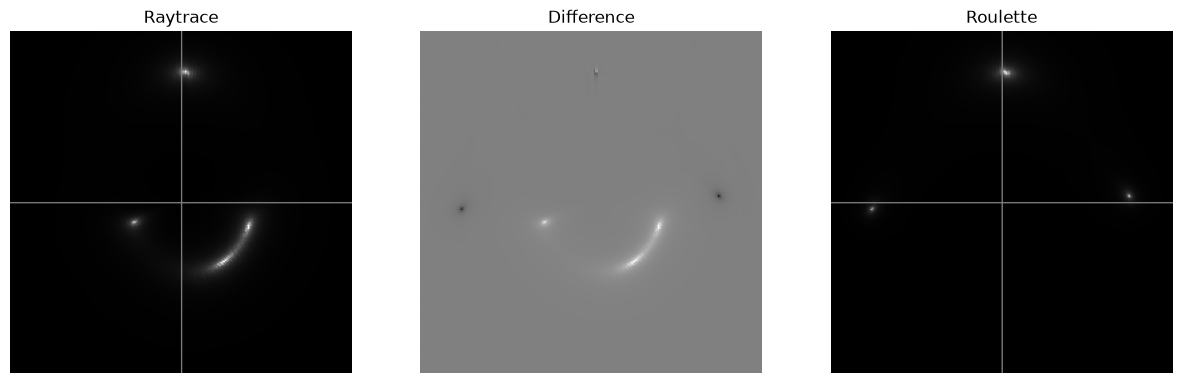

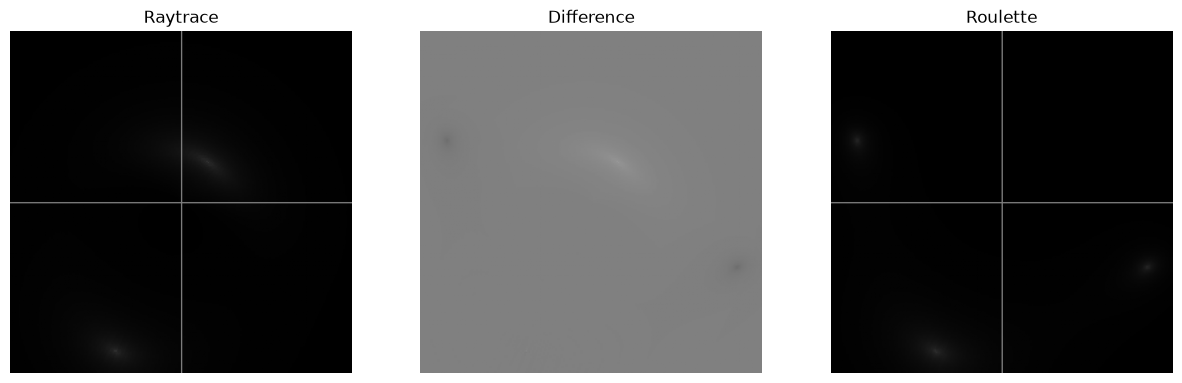

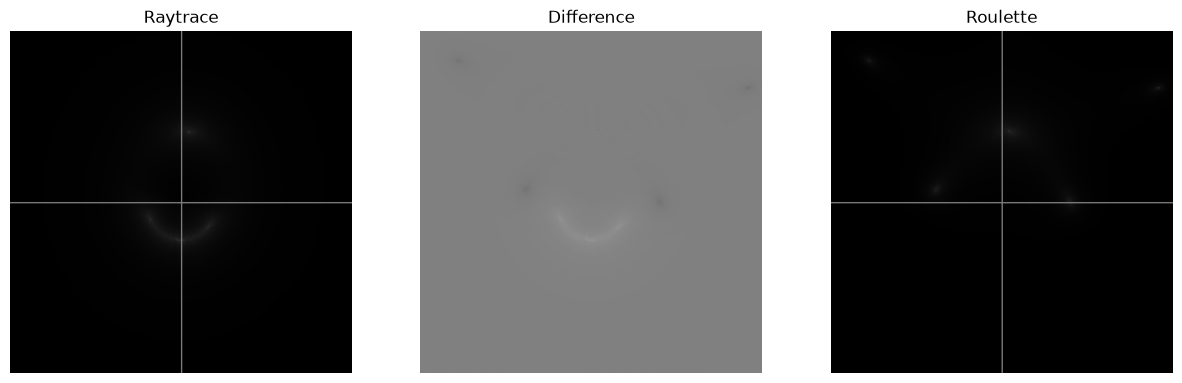

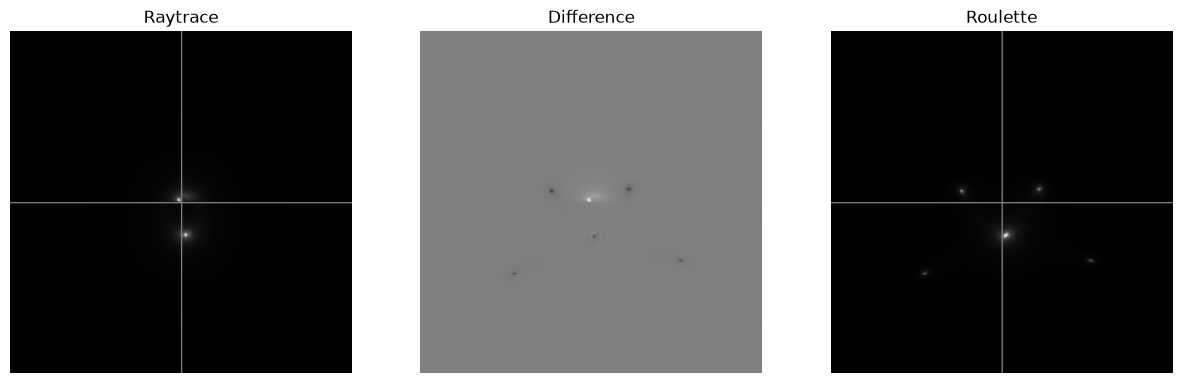

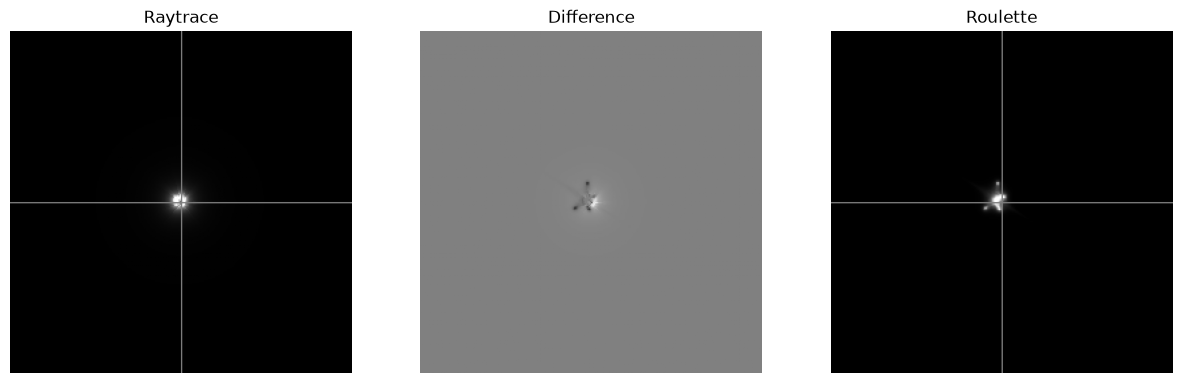

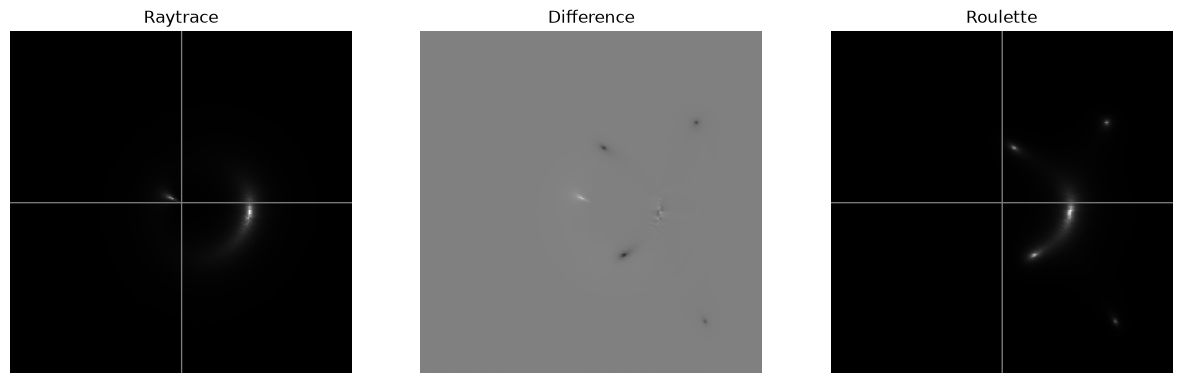

In [20]:
for index, row in df.iterrows():
    param.setRow( row )
    param["simulator"]["centred"] = False
    imsim = SimImage( param, verbose=0 )
    ray = imsim.getImage()
    rr = imsim.getData()
    rou = Resim( rr, rp, verbose=0 ).getImage()
    csimg.imageCompare( ray, rou, "Raytrace", "Roulette", axiscross=True ) 

Here we see a minor discrepancy between the resimulation and the original
simulation in some of the images.


## Closure

This comparison shows good match between raytrace and roulette, except possibly for small images close to the origin.
It also demonstrates that the new mode of operation in v3.3 is a
necessary improvement.